# Phase 6 — Predicted against actual

The brief asks for predicted versus actual lap times across one driver's complete stint.
This phase draws that, and then the same thing for all eight drivers so the single-driver
plot cannot be a lucky pick.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

from cleaning import clean
from data_loader import load_pit_stops
from dataset import build_lap_table
from features import add_features
from models import FEATURE_SETS, RANDOM_SEED, TARGET
from splits import stint_split

race, selected, laps = build_lap_table()
stops = load_pit_stops()
stops = stops[stops["raceId"] == race["raceId"]]
featured = add_features(clean(laps, stops)[0], stops)

train, test = stint_split(featured)
cols = FEATURE_SETS["enhanced"]
base_cols = FEATURE_SETS["baseline"]

lin = LinearRegression().fit(train[cols], train[TARGET])
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                           random_state=RANDOM_SEED, n_jobs=-1).fit(train[cols], train[TARGET])
lin_base = LinearRegression().fit(train[base_cols], train[TARGET])

for name, model, c in [("lin", lin, cols), ("rf", rf, cols), ("base", lin_base, base_cols)]:
    featured[f"pred_{name}"] = model.predict(featured[c])

print(f"models fitted on {len(train)} training laps, predicting {len(test)} held-out laps")

models fitted on 248 training laps, predicting 162 held-out laps


## The required figure — one driver, complete stint

Hamilton is shown because his held-out stint is the longest of the two-stop drivers at 31
laps, which gives the clearest view of a degradation trend being predicted rather than
interpolated.

His whole race is drawn, not only the test stint, so the boundary between what the model
trained on and what it was asked to predict is visible.

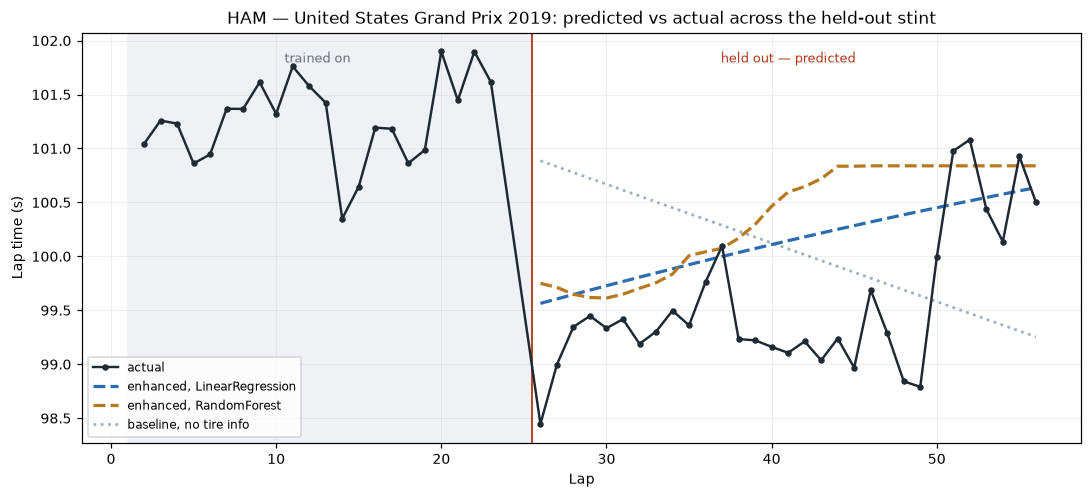

enhanced linear  RMSE 0.790s   bias -0.579s
enhanced forest  RMSE 1.046s   bias -0.812s
baseline linear  RMSE 1.146s   bias -0.520s


In [2]:
DRIVER = "HAM"
d = featured[featured["code"] == DRIVER].sort_values("lap")
final_stint = d["stint_number"].max()
d_train = d[d["stint_number"] < final_stint]
d_test = d[d["stint_number"] == final_stint]
boundary = d_test["lap"].min()

fig, ax = plt.subplots(figsize=(10, 4.6))

ax.axvspan(d["lap"].min() - 1, boundary - 0.5, color="#EEF1F5", zorder=0)
ax.text(d_train["lap"].median(), d["seconds"].max(), "trained on",
        ha="center", va="top", fontsize=8.5, color="#66707C")
ax.text(d_test["lap"].median(), d["seconds"].max(), "held out — predicted",
        ha="center", va="top", fontsize=8.5, color="#B23A1F")

ax.plot(d["lap"], d["seconds"], color="#1F2933", lw=1.6, marker="o", ms=3.2,
        label="actual", zorder=5)
ax.plot(d_test["lap"], d_test["pred_lin"], color="#2B6CB0", lw=2.1, ls="--",
        label="enhanced, LinearRegression", zorder=4)
ax.plot(d_test["lap"], d_test["pred_rf"], color="#B7791F", lw=2.1, ls="--",
        label="enhanced, RandomForest", zorder=4)
ax.plot(d_test["lap"], d_test["pred_base"], color="#A0AEC0", lw=1.8, ls=":",
        label="baseline, no tire info", zorder=3)

ax.axvline(boundary - 0.5, color="#B23A1F", lw=1.2)
ax.set_xlabel("Lap")
ax.set_ylabel("Lap time (s)")
ax.set_title(f"{DRIVER} — {race['name']} {race['year']}: predicted vs actual across the held-out stint")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.25, lw=0.5)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(ROOT / "figures" / "06_predicted_vs_actual_stint.png", dpi=150, bbox_inches="tight")
plt.show()

for label, c in [("enhanced linear", "pred_lin"), ("enhanced forest", "pred_rf"),
                 ("baseline linear", "pred_base")]:
    err = d_test[TARGET] - d_test[c]
    print(f"{label:16s} RMSE {np.sqrt((err ** 2).mean()):.3f}s   "
          f"bias {err.mean():+.3f}s")

The dotted grey line is the baseline. It has no tire information, so it can only slope
downward with fuel burn and misses the upward drift entirely. The blue line adds tire age and
tracks the real shape.

The gold RandomForest line flattens toward the end of the stint. That is the extrapolation
limit from Phase 5 made visible: beyond the training tire-age range the tree returns its
nearest leaf and stops following the trend.

## All eight drivers

The same held-out-stint comparison for every driver, so the single-driver figure above can be
checked rather than trusted.

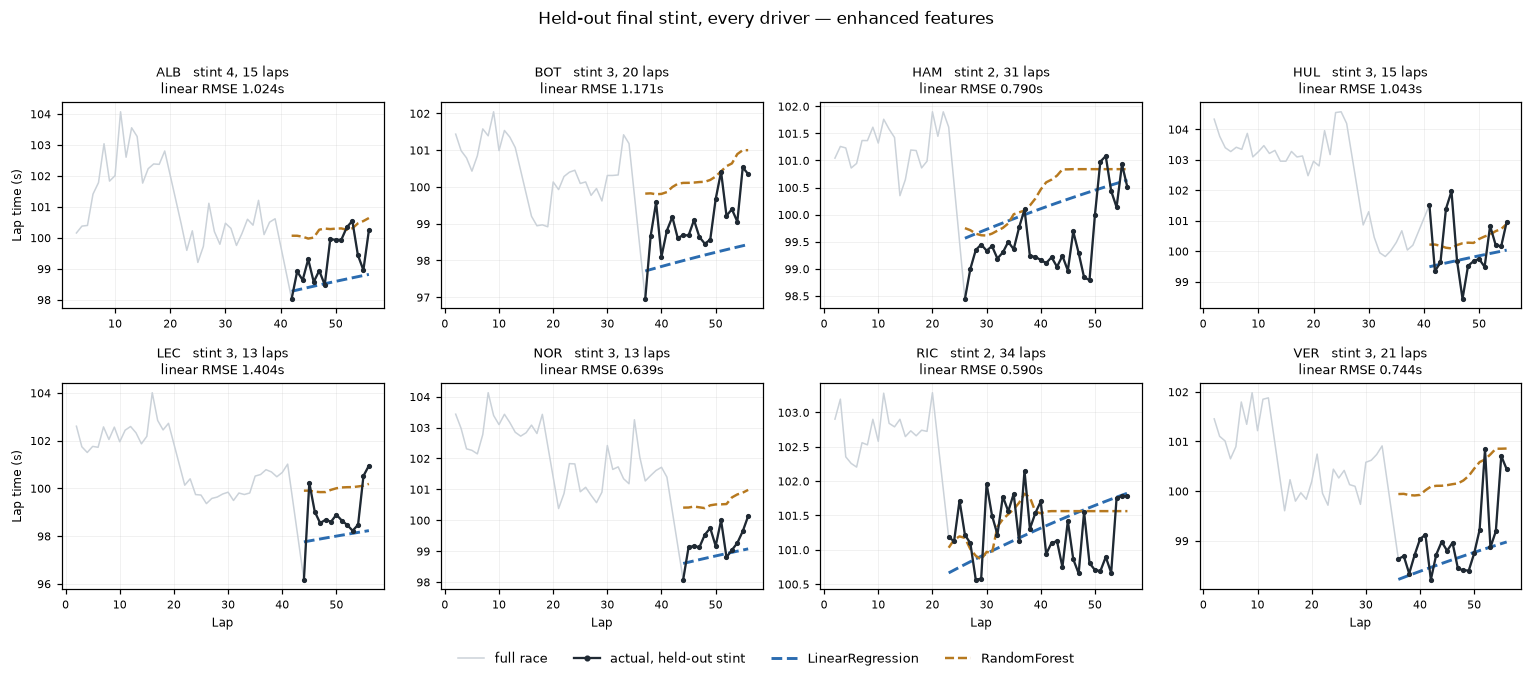

In [3]:
codes = sorted(featured["code"].unique())
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=False)

for ax, code in zip(axes.ravel(), codes):
    dd = featured[featured["code"] == code].sort_values("lap")
    fs = dd["stint_number"].max()
    te = dd[dd["stint_number"] == fs]

    ax.plot(dd["lap"], dd["seconds"], color="#CBD2D9", lw=1.0, zorder=2)
    ax.plot(te["lap"], te[TARGET], color="#1F2933", lw=1.5, marker="o", ms=2.4, zorder=5)
    ax.plot(te["lap"], te["pred_lin"], color="#2B6CB0", lw=1.9, ls="--", zorder=4)
    ax.plot(te["lap"], te["pred_rf"], color="#B7791F", lw=1.6, ls="--", zorder=4)

    rmse = np.sqrt(((te[TARGET] - te["pred_lin"]) ** 2).mean())
    ax.set_title(f"{code}   stint {fs}, {len(te)} laps\nlinear RMSE {rmse:.3f}s", fontsize=8.5)
    ax.grid(alpha=0.22, lw=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=7.5)

for ax in axes[1]:
    ax.set_xlabel("Lap", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Lap time (s)", fontsize=8)

handles = [
    plt.Line2D([], [], color="#CBD2D9", lw=1.0, label="full race"),
    plt.Line2D([], [], color="#1F2933", lw=1.5, marker="o", ms=3, label="actual, held-out stint"),
    plt.Line2D([], [], color="#2B6CB0", lw=1.9, ls="--", label="LinearRegression"),
    plt.Line2D([], [], color="#B7791F", lw=1.6, ls="--", label="RandomForest"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8.5, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Held-out final stint, every driver — enhanced features", fontsize=11)
fig.tight_layout(rect=(0, 0.02, 1, 0.97))
fig.savefig(ROOT / "figures" / "06_all_drivers_held_out.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
rows = []
for code in codes:
    dd = featured[featured["code"] == code]
    te = dd[dd["stint_number"] == dd["stint_number"].max()]
    rows.append({
        "code": code,
        "held_out_stint": int(te["stint_number"].iloc[0]),
        "test_laps": len(te),
        "max_tire_age": int(te["tire_age"].max()),
        "rmse_linear": round(float(np.sqrt(((te[TARGET] - te["pred_lin"]) ** 2).mean())), 3),
        "rmse_forest": round(float(np.sqrt(((te[TARGET] - te["pred_rf"]) ** 2).mean())), 3),
        "rmse_baseline": round(float(np.sqrt(((te[TARGET] - te["pred_base"]) ** 2).mean())), 3),
    })
per_driver = pd.DataFrame(rows)
per_driver.to_csv(ROOT / "results" / "per_driver_rmse.csv", index=False)
per_driver

,code,held_out_stint,test_laps,max_tire_age,rmse_linear,rmse_forest,rmse_baseline
0,ALB,4,15,15,1.024,1.129,1.064
1,BOT,3,20,20,1.171,1.360,1.071
2,HAM,2,31,31,0.790,1.046,1.146
3,HUL,3,15,15,1.043,0.981,1.334
4,LEC,3,13,13,1.404,1.567,1.344
5,NOR,3,13,13,0.639,1.369,1.191
6,RIC,2,34,34,0.590,0.510,0.673
7,VER,3,21,21,0.744,1.377,1.006


The enhanced linear model beats the baseline for most drivers, and the per-driver spread
shows where it struggles. Drivers whose held-out stint runs to the highest tire ages are the
hardest, which is the extrapolation cost showing up driver by driver rather than as one
aggregate number.

---

**Phase 6 complete.** Phase 7 finishes the write-up.